# MELTYQ Figure 8 forward comparison: implementation, responsibilities, and interpretation

**Document status:** This English document is a translation of the [Japanese master Sphinx document](../../ja/meltyq/meltyq_figure8_forward_comparison_ja.html) / [Japanese notebook source](https://github.com/HajimeKawahara/exoexamples/blob/main/docs/ja/meltyq/meltyq_figure8_forward_comparison_ja.ipynb) / [Japanese RST source](https://github.com/HajimeKawahara/exoexamples/blob/main/docs/ja/meltyq/meltyq_figure8_forward_comparison_ja.rst). If an interpretation differs between the two documents, the Japanese version is authoritative.

This document explains what [examples/meltyq/meltyq_figure8.py](https://github.com/HajimeKawahara/exoexamples/blob/main/examples/meltyq/meltyq_figure8.py) computes, which operations are supplied by the ExoFamily providers (ExoGibbs, ExoEOS, and ExoJAX), which role is filled by the external third-party ExoPie dependency, and how far the results can be compared with Figure 8 of [Ito & Changeat (2026), ApJ 1006:37](https://doi.org/10.3847/1538-4357/ae6917). The scope is a **forward-curve comparison at the same displayed coordinates**. It is neither a reimplementation of the full MELTYQ retrieval nor an exact reproduction of unpublished numerical results.

The article and its figures are CC BY 4.0. Paper-curve values used below are coordinates extracted from the centerlines of the public vector PDFs, not the authors' numerical calculation table.

## 1. Execution setup and reproducibility

The next cell locates the repository root and loads both the ordinary run and a sensitivity run in which the C/N input bases are aligned. Results are generated when missing, when the fingerprint of calculation sources and installed package versions changes, or when a generated CSV/PNG no longer matches its recorded hash. The ordinary output is stored under `outputs/meltyq_figure8/`; the basis-aligned output is stored under `outputs/meltyq_figure8_basis_aligned/`. They are generated artifacts and are not tracked by git.

In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start=Path.cwd().resolve()):
    for candidate in (start, *start.parents):
        if (candidate / "examples" / "meltyq" / "meltyq_figure8.py").is_file():
            return candidate
    raise RuntimeError("ExoExamples repository root was not found.")


REPO_ROOT = find_repo_root()
DOCS_DIRECTORY = REPO_ROOT / "docs" / "meltyq"
if str(DOCS_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(DOCS_DIRECTORY))

from meltyq_figure8_document_support import (
    CARBON_BASIS_FACTOR,
    NITROGEN_BASIS_FACTOR,
    FORTNEY_CORE_RADIUS_REARTH,
    PAPER_COMPOSITION_HALF_LINEWIDTH_DEX,
    PAPER_RADIUS_HALF_LINEWIDTH_REARTH,
    SPECIES,
    build_comparison,
    load_document_data,
    plot_architecture,
    plot_basis_aligned_differences,
    plot_basis_aligned_overlay,
    plot_basis_mapping_effect,
    plot_forward_curves,
    runtime_versions,
)

DATA = load_document_data(REPO_ROOT)
RAW = DATA["raw"]
ALIGNED = DATA["aligned"]
REFERENCE = DATA["reference"]
COMPARISON = build_comparison(DATA)

print(f"Repository: {REPO_ROOT}")
print(f"Executable: {sys.executable}")
print(f"Raw rows: {len(RAW)}, basis-aligned rows: {len(ALIGNED)}")
print(f"Published vector vertices: {len(REFERENCE)}")
print(
    "Generated in this execution: "
    f"raw={DATA['raw_generated']}, aligned={DATA['aligned_generated']}"
)
for label, metadata in (
    ("raw", DATA["raw_metadata"]),
    ("basis-aligned", DATA["aligned_metadata"]),
):
    provenance = metadata["document_cache"]
    print(
        f"{label} generated at {provenance['generated_at_utc']} "
        f"with fingerprint {provenance['calculation_fingerprint'][:12]}"
    )

versions = runtime_versions()
packages = ("jax", "exogibbs", "exoeos", "exojax", "exopie")
print(f"Python {versions['python']}")
for package in packages:
    print(f"{package} {versions[package]}")

Repository: /home/kawahara/exoexamples
Executable: /home/kawahara/anaconda3/envs/myenv39/bin/python
Raw rows: 77, basis-aligned rows: 77
Published vector vertices: 959
Generated in this execution: raw=False, aligned=False
raw generated at 2026-08-26T01:20:15.558857+00:00 with fingerprint 2119c377fe38
basis-aligned generated at 2026-08-26T01:20:42.409887+00:00 with fingerprint cd088d34a2b8
Python 3.9.19
jax 0.4.30
exogibbs 0.5.1.dev35+g01b21d4a7.d20260821
exoeos 0.1.1.dev29+gde99829ef
exojax 2.4.1.dev127+gcde2bda1f.d20260821
exopie 2.1.0


## 2. Responsibility boundaries and data flow

The principle in [interface_ja.md](https://github.com/HajimeKawahara/exoexamples/blob/main/interface_ja.md) is that a provider publishes general physical quantities, a consumer owns its port, and a pair-specific adapter appears only once under the consumer's `interop`. This example connects the packages as an application without changing that boundary.

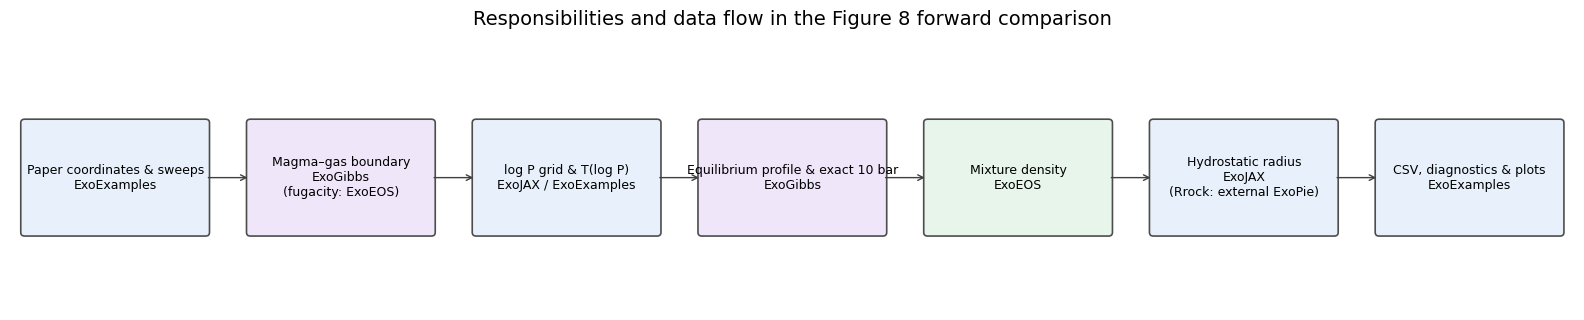

In [2]:
plot_architecture("en")
plt.show()

| Component | Responsibility in this workflow | Boundary implementation |
|---|---|---|
| [ExoGibbs](https://github.com/HajimeKawahara/exogibbs) | Gas equilibrium, magma--gas coupling, and convergence diagnostics | `gas.solve`, `gas.solve_profile`, `magma_gas.solve` |
| [ExoEOS](https://github.com/HajimeKawahara/exoeos) | Pure-component fugacity/EOS and a mixture-density provider | The ExoGibbs-owned `exogibbs.interop.exoeos.make_pure_lnphi_func` and the array contract |
| [ExoJAX](https://github.com/HajimeKawahara/exojax) | Pressure grid, hydrostatic radius integration, and molecular weights | `pressure_layer_logspace_from_boundaries`, `hydrostatic_radius_profile` |
| [ExoPie](https://github.com/mplotnyko/exopie/) | Third-party rocky-body mass--radius interpolation; **not an ExoFamily component** | Scalar $R_{\mathrm{rock}}$ returned by `get_radius`; method described by [Plotnykov & Valencia (2024)](https://doi.org/10.1093/mnras/stae993) |
| [ExoExamples](https://github.com/HajimeKawahara/exoexamples) | Physical choices, package wiring, input conversion, sweeps, continuation, failure policy, CSV, and figures | [meltyq_figure8.py](https://github.com/HajimeKawahara/exoexamples/blob/main/examples/meltyq/meltyq_figure8.py) |

ExoFamily in this document means the three providers ExoGibbs, ExoEOS, and ExoJAX. ExoPie is an independently developed third-party package consumed by ExoExamples; it is not part of ExoFamily. Its output is the radius of the whole rocky body, denoted $R_{\mathrm{rock}}$, rather than the radius of the metallic core. See the [ExoPie repository](https://github.com/mplotnyko/exopie/) and [Plotnykov & Valencia (2024)](https://doi.org/10.1093/mnras/stae993).

`meltyq_figure8.py` reuses only the species-name mapping, the H2--He density projection, and the density-provider construction from [meltyq_clear_forward.py](https://github.com/HajimeKawahara/exoexamples/blob/main/examples/meltyq/meltyq_clear_forward.py). It does not run the opacity or transmission-radiative-transfer stages from that example. Thus, *forward* here means a map from the magma surface through the deep atmosphere to the 10-bar radius. Spectra, clouds, and retrieval posteriors are outside this document's scope.

### Cross-package unit contract

| Call | Input units | Output units | Conversion in ExoExamples |
|---|---|---|---|
| ExoGibbs chemistry | K; bar; dimensionless mole coordinates | Mole fractions; diagnostics | Only the paper C/N coordinates are explicitly mapped |
| ExoEOS density | K; Pa; mole fractions | kg/m3 | bar to Pa: multiply by 1e5 |
| ExoJAX hydrostatic radius | bar; g/cm3; g; cm | cm | kg/m3 to g/cm3: multiply by 1e-3; Earth masses to g; Earth radii to cm |
| ExoPie rocky radius | Earth masses; dimensionless composition | Earth radii | Convert to cm with RE immediately before the ExoJAX call |

These conversions are application responsibilities at package boundaries. In particular, passing bar directly to the ExoEOS density call or kg m$^{-3}$ directly to ExoJAX can produce a running calculation with a physically wrong radius.

## 3. Following one calculation point from input to output

Rather than listing equations as disconnected components, this section follows one set of `Figure8Parameters` through Stages 0--6 to the final plotted quantities. The key structure is a nested solve: an **inner gas-equilibrium solve at fixed elemental amounts** is embedded in an **outer root solve that searches for the element ratios satisfying the magma--gas boundary conditions**. “One path” here means that one set of external inputs leads along one main route to one set of final outputs; it does not mean that every stage is evaluated only once. Stages 1--3 cycle until the outer root converges, and only then does the calculation proceed to Stage 4.

### 3.1 First distinguish inputs, unknowns, and outputs

Write the dynamic inputs supplied for each point as

$$
\boldsymbol z=\left(P_{melt},T_{melt},f_{O_2}^{target},Q_C^{target},Q_N^{target},T_b\right).
$$

The `Figure8Parameters` fields `oxygen_fugacity_bar`, `co_melt_mole_ratio`, and `n_melt_mole_ratio` correspond to $f_{O_2}^{target}$, $Q_C^{target}$, and $Q_N^{target}$, respectively. The superscript `target` is not part of the implementation field names. It is notation used here to distinguish an externally prescribed value that the outer root must match at convergence. **It does not mean a Newton initial value.**

The three targets are magma--gas boundary conditions assumed by this forward model.

- $f_{O_2}^{target}$ is the prescribed molecular-O2 fugacity [bar] at the magma surface. It is the redox condition $f_{O_2}^{gas}=f_{O_2}^{target}$ at convergence and also sets $\Delta\mathrm{IW}$ in the N-solubility law. It is not an O-atom abundance.
- $Q_C^{target}$ is the prescribed dilute solute-to-melt-matrix mole ratio of dissolved elemental C. At convergence it matches the $Q_C$ predicted by the C-solubility law from the trial gas's $f_{CO}$. It is not the gas mole fraction $x_{CO}$.
- $Q_N^{target}$ is the prescribed atomic dilute solute-to-melt-matrix mole ratio of total dissolved elemental N. At convergence it matches the $Q_N$ predicted by the N-solubility law from the trial gas's $p_{N_2}$ and other inputs. It is not the gas mole fraction $x_{N_2}$.

Thus $Q_C^{target}$ and $Q_N^{target}$ are neither the total C/N inventory of a finite magma reservoir nor an initial composition for a time evolution. This example treats them as conditions that the specified melt-side concentrations equal the equilibrium (saturation) concentrations predicted by the empirical solubility laws for the gas. Numerical initialization is the separate quantity $\boldsymbol u^{(0)}$. The first-point `initial_root(conditions)` also uses the target values to construct a heuristic seed, whereas subsequent sweep points can use the preceding converged solution. Changing the seed does not change the target conditions.

The first unknown obtained from $\boldsymbol z$ is the vector of four log element ratios, with H fixing the amount-scale gauge,

$$
\boldsymbol u=\left(\ln\frac{b_C}{b_H},\ln\frac{b_O}{b_H},\ln\frac{b_N}{b_H},\ln\frac{b_{He}}{b_H}\right),\qquad
\boldsymbol b(\boldsymbol u)=(1,e^{u_C},e^{u_O},e^{u_N},e^{u_{He}}).
$$

A common scale factor applied to all five elemental amounts does not change gas mole fractions, so $b_H=1$. This is an amount gauge, not the physical assertion that there is one mole of hydrogen; $\boldsymbol b$ is neither an element mole-fraction vector nor the total inventory of a finite reservoir. Crucially, $\boldsymbol z\mapsto\boldsymbol u^*$ is not an explicit substitution. It is the implicit solution of the four conditions defined in Section 3.5,

$$
\boldsymbol F(\boldsymbol z,\boldsymbol u^*)=\boldsymbol0,\qquad
\boldsymbol u^*(\boldsymbol z)=\operatorname{Root}_{\boldsymbol u}\boldsymbol F(\boldsymbol z,\boldsymbol u).
$$

The notation `z→u` therefore contains the Stage 1--3 iteration and the inner gas solve performed by every residual evaluation. In terms of their unknowns and roles:

- **Inner solve:** fix $T_{melt},P_{melt}$ and $\boldsymbol b^{(k)}$ constructed from one trial $\boldsymbol u^{(k)}$, then minimize the gas Gibbs energy under element balance to obtain the species amounts $\boldsymbol n$ and gas composition.
- **Outer solve:** treat $\boldsymbol u$ as the unknown, repeatedly call the inner solve, construct four residuals from the resulting gas fugacities and solubilities, and update the element ratios until those residuals vanish. It is not a Gibbs minimization of the combined melt+gas system.

The fixed conditions are

$$
P_b=10\,\mathrm{bar},\quad h=0.84,\quad M_p=4M_\oplus,\quad
\mathrm{CMF}=0.33,\quad N_{layer}=64,\quad Y_{density}=0.275.
$$

The roles of the quantities appearing in the calculation are listed first to avoid conflating them.

| Symbol | Kind | Meaning | Normalization or role in the next stage |
|---|---|---|---|
| $b_e$ | Elemental amount determined by the outer solve | H/C/O/N/He atom amount passed to the gas-equilibrium problem | Uses $b_H=1$ as a gauge; it is not the total inventory of a finite magma+gas reservoir |
| $n_s$ | Unknown in the inner solve | Unnormalized amount of each gas species | Satisfies $A\boldsymbol n=\boldsymbol b$ |
| $x_s=n_s/n_{tot}$ | Output of the inner solve | Gas-phase mole fraction | Forms $p_s=x_sP$ and $f_s=\phi_sx_sP$ |
| $Y_\alpha$ | Native output of a solubility law | Dissolved concentration when the law returns a melt mass fraction | The basis depends on the species |
| $Q_\alpha$ | Melt quantity after basis conversion | Dilute solute-to-melt-matrix mole ratio | Only $Q_C$ and $Q_N$ enter the outer residual |
| $\rho_j,r_j$ | Unknown/output of the deep-structure calculation | Layer density and pressure-boundary radius | Ultimately gives $R_{10\,bar}=r_0$ |

Thus this is not a single calculation that takes a melt composition and returns a gas composition. The outer solver adjusts the element ratios supplied to the gas until the input $Q_C^{target},Q_N^{target}$ match the $Q_C,Q_N$ predicted from the trial gas by the solubility laws.

### 3.2 Stage map: governing equations and implementation APIs

| Stage | Given | Unknowns and governing equations | Actual call | Quantity passed onward |
|---|---|---|---|---|
| 0. Build the problem | Thermochemical catalog, species, and EOSs | No numerical unknown | `chemsetup` → `make_pure_lnphi_func` → `prepare_meltyq_problem` | ExoGibbs `MagmaGasProblem` |
| 1. Outer trial | $\boldsymbol z$ and trial $\boldsymbol u$ | $\boldsymbol b(\boldsymbol u)=(1,e^{u_C},e^{u_O},e^{u_N},e^{u_{He}})$ | `MeltyqMagmaGasModel.element_abundances` | Trial $\boldsymbol b$ |
| 2. Inner gas equilibrium | $(T_{melt},P_{melt},\boldsymbol b)$ | Gibbs minimization with $A\boldsymbol n=\boldsymbol b$ | Public entry point `magma_gas.solve` runs the gas-equilibrium engine internally | $\boldsymbol x,\boldsymbol p,\boldsymbol f$ |
| 3. Boundary closure | Gas state and targets $f_{O_2},Q_C,Q_N,h$ | Evaluate the solubility relations and solve four residuals $\boldsymbol F(\boldsymbol u)=0$ | `MeltyqMagmaGasModel.evaluate` and the damped root solver in `magma_gas.solve` | $\boldsymbol b^*$, surface gas, and dissolved-concentration predictions |
| 4. Deep chemistry | $\boldsymbol b^*$ and prescribed $P_j,T_j$ | The same gas Gibbs equilibrium in every layer | `gas.solve_profile`; `gas.solve` at the endpoint | $\boldsymbol x(P_j)$ and the exact 10-bar gas |
| 5. Density | $\boldsymbol x(P_j),T_j,P_j$ | Density-only H2--He projection and additive volumes | `make_density_provider(...).mass_density_tp` | $\rho(P_j)$ |
| 6. Radius | $\rho(P_j),M_p,R_{rock}$ | $dP/dr=-\rho GM_p/r^2$ | External `exopie.get_radius`; ExoJAX `hydrostatic_radius_profile` | $R_{10\,bar}$ |

Viewed externally, the single main data flow is

$$
\boldsymbol z
\longrightarrow
\left[\boldsymbol u^*(\boldsymbol z):\ \boldsymbol F(\boldsymbol z,\boldsymbol u^*)=\boldsymbol0\right]
\longrightarrow\boldsymbol b^*
\longrightarrow\left(\boldsymbol x_{surface},\boldsymbol x(P)\right)
\longrightarrow\rho(P)\longrightarrow R_{10\,bar}.
$$

The bracketed part is not a one-pass map; it is the feedback loop

$$
\boldsymbol u^{(k)}\to\boldsymbol b^{(k)}
\xrightarrow{\mathrm{inner\ GasEq}}(\boldsymbol x^{(k)},\boldsymbol p^{(k)},\boldsymbol f^{(k)})
\xrightarrow{\mathrm{solubility}}\boldsymbol F^{(k)}
\xrightarrow{\mathrm{outer\ update}}\boldsymbol u^{(k+1)}.
$$

The radius calculation also has a separate branch,

$$
(M_p,\mathrm{CMF},x_{Si},x_{Fe})\xrightarrow{\text{external ExoPie}}R_{rock},
$$

which joins the atmospheric branch in the final hydrostatic integration. $R_{rock}$ is not an ExoFamily output.

### 3.3 Stage 0: build the ExoGibbs problem once

`build_context` first obtains the source `ChemicalSetup` from `exogibbs.presets.fastchem4.chemsetup(silent=True)`. The ExoGibbs-owned adapter `exogibbs.interop.exoeos.make_pure_lnphi_func(...)` then converts the ExoEOS Zhang--Duan EOSs to the `lnphi_func(T, P_bar, None)` contract. Finally it calls

```python
problem = prepare_meltyq_problem(
    source_setup, lnphi_func=source_lnphi, species_map=SPECIES_MAP
)
```

The returned `MagmaGasProblem` bundles three objects: `problem.setup`, reduced to the nine species; `problem.model`, which defines the outer mapping and residual; and `problem.lnphi_func`, which supplies the non-ideality correction. No root for an individual calculation point is solved at this stage. Sharing this static object across all sweep points avoids rebuilding the thermochemistry, formula matrix, and EOS closure point by point.

### 3.4 Stages 1--2: from an outer trial to gas Gibbs equilibrium

In an ordinary gas-only equilibrium calculation, $(T,P,\boldsymbol b)$ are all inputs. The solver neither creates nor destroys elements; it redistributes the atoms in $\boldsymbol b$ among the allowed gas species. What differs at the MELTYQ boundary is that $\boldsymbol b$ itself is unknown and is rebuilt from each outer-root trial $\boldsymbol u$.

The public call for the entire boundary calculation is `exogibbs.api.magma_gas.solve`. ExoExamples does not manually call `gas.solve` inside an outer loop. Instead, `magma_gas.solve` (1) applies $\boldsymbol u\mapsto\boldsymbol b$ through `problem.model.element_abundances`, (2) runs the ExoGibbs gas-equilibrium engine inside every outer-residual evaluation, and (3) evaluates the solubility relations and four residuals through `problem.model.evaluate`. The actual call has the form

```python
boundary = magma_gas.solve(
    problem,
    temperature_k=temperature_melt_k,
    pressure_bar=pressure_melt_bar,
    model_inputs=MeltyqMagmaGasInputs(
        oxygen_fugacity_bar=oxygen_fugacity_target_bar,
        co_melt_mole_ratio=carbon_melt_target,
        n_melt_mole_ratio=nitrogen_melt_target,
    ),
    init=magma_gas.MagmaGasInit(root_variables=root_initial),
    options=magma_gas.MagmaGasOptions(max_iter=100),
)
```

For the first point, `root_initial` is the Newton seed constructed by `problem.model.initial_root(conditions)`; during a sweep it is the preceding converged root. It is a numerical initial guess, not an additional physical condition. This warm-starts only the outer variable $\boldsymbol u$. The current ExoGibbs `magma_gas.solve` does not carry the inner $(\ln\boldsymbol n,\ln n_{tot})$ state between outer trials; every trial's inner gas solve uses the default initializer.

Take the element order to be $(\mathrm H,\mathrm C,\mathrm O,\mathrm N,\mathrm{He})$ and the species order to be $(\mathrm{H_2},\mathrm{He},\mathrm{O_2},\mathrm{H_2O},\mathrm{CO},\mathrm{CO_2},\mathrm{CH_4},\mathrm{N_2},\mathrm{NH_3})$. The $5\times9$ stoichiometric formula matrix containing the number of atoms is

$$
A=\begin{pmatrix}
2&0&0&2&0&0&4&0&3\\
0&0&0&0&1&1&1&0&0\\
0&0&2&1&1&2&0&0&0\\
0&0&0&0&0&0&0&2&1\\
0&1&0&0&0&0&0&0&0
\end{pmatrix},\qquad \mathrm{rank}(A)=5.
$$

Let the gas amounts be $n_s>0$, with $n_{tot}=\sum_s n_s$ and $x_s=n_s/n_{tot}$. Conceptually, the inner problem has 15 unknowns: nine $n_s$, one $n_{tot}$, and five elemental Lagrange multipliers $\pi_e$. To preserve positivity, ExoGibbs numerically iterates mainly in $\ln n_s$ and $\ln n_{tot}$ and obtains $\boldsymbol\pi$ at each step. Let $h_s^{FC4}(T)$ be the dimensionless standard-state term read from the FastChem4 thermochemical catalog and $\phi_s(T,P)$ the pure-component fugacity coefficient. Then

$$
h_s^{eff}=h_s^{FC4}+\ln\phi_s,\qquad
g_s=\frac{\mu_s}{RT}=h_s^{eff}+\ln x_s+\ln\frac{P}{P^\circ},
\qquad P^\circ=1\,\mathrm{bar}.
$$

The ExoGibbs inner solve minimizes Gibbs energy subject to $A\boldsymbol n=\boldsymbol b$:

$$
\boldsymbol n^*=\arg\min_{\boldsymbol n>0}
\frac{G}{RT}
=\arg\min_{\boldsymbol n>0}
\sum_s n_s\left[h_s^{eff}+\ln\frac{n_s}{n_{tot}}+\ln\frac{P}{P^\circ}\right].
$$

The 15 simultaneous KKT conditions implemented by the solver comprise five element balances, one definition of total amount, and nine stationarity conditions:

$$
A\boldsymbol n=\boldsymbol b,\qquad n_{tot}=\sum_s n_s,\qquad
\boldsymbol g=A^{\mathsf T}\boldsymbol\pi.
$$

The implementation residual used to test inner convergence is

$$
\epsilon_{inner}^2=
\sum_s\left[n_s\{(A^{\mathsf T}\boldsymbol\pi)_s-g_s\}\right]^2
+\|A\boldsymbol n-\boldsymbol b\|_2^2
+\left(\sum_s n_s-n_{tot}\right)^2.
$$

`exogibbs.api.gas.solve` is the public alias for this single-layer gas-only problem, and the inner engine of `magma_gas.solve` uses the same Gibbs-minimization kernel. The returned `EquilibriumResult` fields `n`, `ntot`, and `x` are $\boldsymbol n,n_{tot},\boldsymbol x$, respectively. It follows that $p_s=x_sP$ and $f_s=\phi_sx_sP$. Here $p_s$ is the species' pressure share in the mixture, whereas $f_s$ is the effective pressure entering its chemical potential through the non-ideality correction. For an ideal gas, $\phi_s=1$ and $f_s=p_s$.

For H2/O2/H2O/CO/CO2/CH4, $\phi_s$ comes from the ExoEOS Zhang--Duan pure-component EOS; He/N2/NH3 use $\phi_s=1$. This is not a composition-dependent mixture-fugacity model. Because $\mathrm{nullity}(A)=4$, one possible independent reaction basis is

$$
\mathrm{O_2}+2\mathrm{H_2}\rightleftharpoons2\mathrm{H_2O},\quad
2\mathrm{CO}+\mathrm{O_2}\rightleftharpoons2\mathrm{CO_2},\quad
\mathrm{CO}+3\mathrm{H_2}\rightleftharpoons\mathrm{CH_4}+\mathrm{H_2O},\quad
\mathrm{N_2}+3\mathrm{H_2}\rightleftharpoons2\mathrm{NH_3}.
$$

The KKT conditions imply $\prod_s(f_s/P^\circ)^{\nu_{rs}}=K_r(T)$ for these four reactions. The solver does not impose four separately hand-coded reaction equations. Condensates and ions do not appear because they are absent from the network.

### 3.5 Stage 3: solubility laws and the outer magma--gas boundary root

#### What is a solubility law?

When a gas contacts a silicate melt, volatile species can reside in the melt as well as in the gas. A complete two-phase thermodynamic model would solve chemical-potential equality between the phases together with a melt activity model. This example does not directly minimize the Gibbs energy of the melt phase. Instead, it uses empirical constitutive relations fitted to experimental data,

$$
Q_\alpha^{sat}=\mathcal S_\alpha\!\left(T_{melt},P_{melt},p_s,f_s,\Delta\mathrm{IW},X_{oxide}\right).
$$

These are what this document calls **solubility laws (empirical equilibrium volatile-solubility relations)**. Given the partial pressure $p_s$ or fugacity $f_s$ of a trial gas, a law returns the **saturated dissolved concentration** in a melt assumed to be in equilibrium with that gas. It is not a rate law for the time evolution of dissolution, a gas mole fraction, or a conservation law for the total volatile inventory.

When a law returns a mass fraction $Y_\alpha$, ExoGibbs uses the mean melt molar mass $\overline M_{melt}=60$ g mol$^{-1}$ and the dilute approximation

$$
Q_\alpha=Y_\alpha\frac{\overline M_{melt}}{M_\alpha}
\simeq\frac{n_\alpha^{dissolved}}{n_{melt\ matrix}}
$$

to convert it to a dilute solute-to-melt-matrix mole ratio. This $Q_\alpha$ is not a finite-concentration mole fraction obtained by renormalizing every component. In particular, $M_\alpha=M_C$ for the CO-bearing law and $M_\alpha=M_N$ for the nitrogen law, so $Q_C$ and $Q_N$ are on elemental-C and atomic-N bases, not CO- and N2-molecule bases.

| Predicted melt quantity | Gas-side driver | ExoGibbs law / basis conversion | Native output | Role in the outer root |
|---|---|---|---|---|
| Dissolved H2 | $f_{H_2}$ [bar], $P_{melt}$ [GPa] | `h2_hirschmann2012` | H2 mole fraction | Prediction only |
| Dissolved H2O | $p_{H_2O}$ [Pa] | `h2o_lichtenberg2021` → `h2o_mass_fraction_to_mole_ratio` | H2O mass fraction | Prediction only |
| Elemental C dissolved from CO-bearing gas | $f_{CO}$ [bar] | `ln_co_yoshioka2019` → `elemental_c_ln_mass_fraction_to_ln_mole_ratio` | Elemental-C mass fraction | $Q_C=Q_C^{target}$ |
| Dissolved CO2 | $p_{CO_2}$ [Pa] | `co2_lichtenberg2021` → `co2_mass_fraction_to_mole_ratio` | CO2 mass fraction | Prediction only |
| Dissolved CH4 | $f_{CH_4}$ [GPa], $P_{melt}$ [GPa] | `ch4_ardia2013` | CH4 mole fraction | Prediction only |
| Total dissolved elemental N | $p_{N_2}$ [GPa], $T,P,\Delta\mathrm{IW},X_{oxide}$ | `ln_n2_dasgupta2022` → `elemental_n_ln_mass_fraction_to_ln_mole_ratio` | Elemental-N mass fraction | $Q_N=Q_N^{target}$ |

Each law is empirical and calibrated over a finite experimental range; the implementation does not automatically clip inputs outside that range. Representative $(T,P_{total})$ ranges recorded in the ExoGibbs metadata are H2: 1673--1773 K, 0.7--3.0 GPa; H2O: 973--1723 K, $10^{-4}$--0.8 GPa; C from CO: 1523--1873 K, 0.2--3.0 GPa; CO2: 1123--1923 K, 0.01--3.0 GPa; CH4: 1673--1723 K, 0.7--3.0 GPa; and N: 1323--2600 K, $10^{-4}$--8.2 GPa. A numerical result at an edge of the Figure 8 sweep therefore does not by itself show that the law has been experimentally validated there.

#### Close four unknowns with four conditions

The four unknowns $\boldsymbol u$ defined in Section 3.1 are closed by the three target conditions and the H2--He condition. For every trial $\boldsymbol u$, the inner equilibrium in Section 3.4 gives $\boldsymbol x(\boldsymbol u)$. Define $P_G=10^{-4}P_{melt,bar}$, $p_{s,Pa}=10^5x_sP_{melt,bar}$, and $f_{s,GPa}=10^{-4}\phi_sx_sP_{melt,bar}$. The implementation then evaluates

$$
\begin{aligned}
Q_{H_2}&=f_{H_2,bar}\exp(-11.403-0.76P_G),\\
Q_{H_2O}&=1.033\times10^{-6}p_{H_2O,Pa}^{1/1.747}\frac{60}{18.01528},\\
Y_C&=10^{-7.2}f_{CO,bar}^{0.8},& Q_C&=Y_C\frac{60}{12.0107},\\
Q_{CO_2}&=1.937\times10^{-15}p_{CO_2,Pa}^{1/0.714}\frac{60}{44.0095},\\
Q_{CH_4}&=f_{CH_4,GPa}\exp(-7.63-1.9P_G).
\end{aligned}
$$

These are the empirical relations of [Hirschmann et al. (2012)](https://doi.org/10.1016/j.epsl.2012.06.031), [Lichtenberg et al. (2021)](https://doi.org/10.1029/2020JE006711), [Yoshioka et al. (2019)](https://doi.org/10.1016/j.gca.2019.06.007), [Lichtenberg et al. (2021)](https://doi.org/10.1029/2020JE006711), and [Ardia et al. (2013)](https://doi.org/10.1016/j.gca.2013.03.028), respectively. $Y_C$ is the elemental-C mass fraction and $Q_C$ is its dilute mole ratio; neither is the gas CO mole fraction. For nitrogen,

$$
\begin{aligned}
\Delta\mathrm{IW}&=\log_{10}\frac{f_{O_2}^{target}}{1\,\mathrm{bar}}-L_{IW}(T_{melt},P_G),\\
a&=\frac{5908\sqrt{P_G}}{T_{melt}}-1.6\Delta\mathrm{IW},\\
c&=4.67+7.11(0.56)-13.06(0.11)-120.67(0.01),\\
Y_N&=10^{-6}\left[p_{N_2,GPa}^{1/2}e^a+p_{N_2,GPa}e^c\right],&
Q_N&=Y_N\frac{60}{14.0067}.
\end{aligned}
$$

$L_{IW}$ is the Hirschmann et al. (2021) iron--wüstite-buffer $\log_{10}f_{O_2}^{IW}$; the fixed values 0.56/0.11/0.01 are the basaltic $X_{SiO_2}/X_{Al_2O_3}/X_{TiO_2}$. Following Dasgupta et al. (2022), $Q_N$ is the atomic dilute ratio of total elemental N, and the reduced term in the present implementation depends on $\sqrt{P_G}$.

Because $\boldsymbol z$ is fixed during one point calculation, the following abbreviates $\boldsymbol F(\boldsymbol z,\boldsymbol u)$ as $\boldsymbol F(\boldsymbol u)$. The four dimensionless logarithmic residuals actually solved by the outer root are

$$
\boldsymbol F(\boldsymbol u)=\begin{pmatrix}
\ln(f_{O_2}^{gas}/f_{O_2}^{target})\\
\ln(Q_C/Q_C^{target})\\
\ln(Q_N/Q_N^{target})\\
\ln(x_{H_2}/x_{He})-\ln[h/(1-h)]
\end{pmatrix}=\boldsymbol0,\qquad h=0.84.
$$

These residuals represent, in order, the redox, melt-C, melt-N, and H2--He conditions. They correspond broadly to O/H, C/H, N/H, and He/H, but every component is coupled through the gas chemistry, so the solver does not adjust the four unknowns independently in one-to-one pairs.

The actual feedback loop is

$$
\boldsymbol u^{(k)}\to\boldsymbol b^{(k)}
\xrightarrow{\mathrm{inner\ GasEq}}(\boldsymbol x^{(k)},\boldsymbol p^{(k)},\boldsymbol f^{(k)})
\xrightarrow{\mathcal S_\alpha}\boldsymbol Q^{(k)}
\to\boldsymbol F^{(k)}
\xrightarrow{\mathrm{damped\ Newton}}\boldsymbol u^{(k+1)}.
$$

The outer step solves $J_F\Delta\boldsymbol u=-\boldsymbol F$ with a JAX-autodifferentiated Jacobian and applies step clipping and a backtracking line search. Convergence is tested using $\|\boldsymbol F\|_\infty=\max_i|F_i|$. The example uses `MagmaGasOptions(max_iter=100)`, an outer tolerance of $10^{-8}$, and audits the final inner gas solve with a tolerance of $10^{-11}$ and at most 1000 iterations.

At convergence, $x_{H_2}/(x_{H_2}+x_{He})=h$ and $\boldsymbol b^*=\boldsymbol b(\boldsymbol u^*)$. The input $f_{O_2}^{target}$ is the fugacity of molecular O2, not an O-atom abundance; O/H is inferred by the root. $\Delta\mathrm{IW}$ is evaluated from the prescribed $f_{O_2}^{target}$, which equals the gas fugacity at convergence. $Q_{H_2}$, $Q_{H_2O}$, $Q_{CO_2}$, and $Q_{CH_4}$ are output predictions rather than outer constraints. This nested solve is neither a Gibbs minimization of the combined melt+gas system nor conservation of the bulk volatile inventory of a finite magma reservoir.

The correspondence between the `boundary` object returned by `magma_gas.solve` and the mathematical quantities is

| Mathematical quantity | ExoGibbs result path | Next use |
|---|---|---|
| $\boldsymbol u^*$ | `boundary.root_variables` | Continuation seed and CSV diagnostics |
| $\boldsymbol b^*$ | `boundary.element_abundances` | Gas equilibrium in every deep layer |
| Surface $\boldsymbol x$ | `boundary.gas.equilibrium.x` | Figure 8 solid curve |
| $\boldsymbol p,\boldsymbol f$ | `boundary.gas.partial_pressures_bar`, `boundary.gas.fugacities_bar` | Solubility laws and diagnostics |
| $(Q_{H_2},Q_{H_2O},Q_C,Q_{CO_2},Q_{CH_4},Q_N)$ | `boundary.model_state.melt_volatile_mole_ratios` | Melt-side predictions; not currently saved in `PointResult` or the CSV |
| Outer/inner convergence information | `boundary.diagnostics` | `outer_converged`, `inner_converged`, residual, and related diagnostics |

### 3.6 Stages 4--5: gas-only equilibrium and density in the deep atmosphere

Only the lower boundary is in contact with magma. Above it, neither the solubility laws nor the outer root are rerun. The same converged $\boldsymbol b^*$ is supplied to every layer, where only **gas-only equilibrium** is solved. Let $P_b=10$ bar be the base of the upper atmosphere. ExoJAX `pressure_layer_logspace_from_boundaries` defines $N=64$ layer boundaries $B_j$ and representative pressures $P_j$ by

$$
B_j=P_b\left(\frac{P_{melt}}{P_b}\right)^{j/N},\qquad
P_j=\sqrt{B_jB_{j+1}},\qquad j=0,\ldots,N-1.
$$

The prescribed temperature profile and the chemical composition in each layer are

$$
T(P)=T_b+(T_{melt}-T_b)\frac{\ln(P/P_b)}{\ln(P_{melt}/P_b)},\qquad
\boldsymbol x(P)=\mathrm{GasEq}[T(P),P,\boldsymbol b^*].
$$

$\boldsymbol b^*$ is fixed with altitude, but $\boldsymbol x$ changes with $T$ and $P$. The implementation uses `exogibbs.api.gas.solve_profile(problem.setup, T, P, boundary.element_abundances, ..., lnphi_func=problem.lnphi_func)` with `EquilibriumOptions(method="scan_hot_from_bottom")`. This is not a new physical model; it is a scheduler that warm-starts the same single-layer `gas.solve` from the preceding layer's $(\ln\boldsymbol n,\ln n_{tot})$.

The uppermost profile layer is centered geometrically between 10 bar and $P_{melt}$, so it is not used for the Figure 8 dotted curve. Seeded by that layer's solution, a separate call to `exogibbs.api.gas.solve(problem.setup, T_b, 10.0, boundary.element_abundances, ...)` produces the exact $(T_b,P_b)$ gas. The imposed $T(P)$ is not a solution of radiative equilibrium, a convective adiabat, or energy balance.

To satisfy the density-table contract, the chemical composition is projected to an H2--He mass fraction $Y=0.275$ only while evaluating density:

$$
m_{HHe}=x_{H_2}M_{H_2}+x_{He}M_{He},\qquad
y_{H_2}=(1-Y)\frac{m_{HHe}}{M_{H_2}},\qquad
y_{He}=Y\frac{m_{HHe}}{M_{He}},\qquad
x_s^{\rho}=\frac{y_s}{\sum_i y_i}.
$$

For the other species, $y_s=x_s$. This projection conserves the H2+He mass and is not fed back into the chemical equilibrium. For EOS group $g$, define

$$
W_g=\frac{\sum_{s\in g}x_s^{\rho}M_s}{\sum_i x_i^{\rho}M_i},\qquad
\frac1{\rho}=\sum_g\frac{W_g}{\rho_g(T,P)}.
$$

The H2--He group uses the Chabrier--Debras table, O2/H2O/CO/CO2/CH4 use Zhang--Duan EOSs, and N2/NH3 use the ideal EOS. ExoExamples' `make_density_provider` assembles these into an ExoEOS `AdditiveVolumeCompositeDensityProvider`, and each layer calls `density_provider.mass_density_tp(T_j, P_j_pa, density_composition_j)`. This stage is an algebraic EOS closure, not another root solve.

### 3.7 Stage 6: external ExoPie lower boundary and hydrostatic radius

[ExoPie](https://github.com/mplotnyko/exopie/) is a third-party interior package outside ExoFamily. Its methodology is described by [Plotnykov & Valencia (2024)](https://doi.org/10.1093/mnras/stae993). The rocky branch of `exopie.get_radius`, called once by `build_context`, does not use an analytic $R\propto M^\alpha$ relation. It interpolates a four-dimensional grid built from SUPEREARTH interior calculations. The present call is

$$
\frac{R_{rock}}{R_\oplus}=\mathcal I_{rocky}(\mathrm{CMF},M_p/M_\oplus,x_{Si}^{core},x_{Fe}^{mantle})
=\mathcal I_{rocky}(0.33,4,0,0)=1.44527308.
$$

Here CMF is the core mass fraction, and the returned $R_{rock}$ is the radius of the entire rocky body, core plus mantle, not the radius of the metallic core. With `wmf=None` and `amf=None`, neither the water nor the envelope branch is used; $P_{melt}$ and $T_{melt}$ are not passed to ExoPie. This is therefore not a self-consistent magma-ocean radius calculation, but an external Dirichlet boundary for which ExoExamples sets $R(P_{melt})=R_{rock}$.

Starting from this lower boundary, ExoJAX `hydrostatic_radius_profile` integrates

$$
\frac{dP}{dr}=-\rho(P)\frac{GM_p}{r^2},\qquad R(P_{melt})=R_{rock}
$$

up to 10 bar. The continuous form and the discrete form with constant density in each layer are

$$
I_\rho=\int_{P_b}^{P_{melt}}\frac{dP}{GM_p\rho(P)},\qquad
R_{10\,bar}=\left(R_{rock}^{-1}-I_\rho\right)^{-1},
$$

$$
\frac1{r_j}=\frac1{R_{rock}}-\sum_{k=j}^{N-1}\frac{B_{k+1}-B_k}{GM_p\rho_k}.
$$

The radial variation $g=GM_p/r^2$ is retained, whereas atmospheric mass and self-gravity are neglected. Changes in $R_{10\,bar}$ therefore reflect not only ExoPie's $R_{rock}$ but also $I_\rho$, which depends on temperature, chemical composition, and EOS density.

### 3.8 Final outputs, types of equations, and domain of applicability

The physical quantities ultimately returned for one calculation point are

$$
\boxed{\left(\boldsymbol x_{surface},\boldsymbol x_{10\,bar},R_{10\,bar}\right)}.
$$

They correspond to `boundary.gas.equilibrium.x`, `base_equilibrium.x`, and `radius_boundaries_cm[0] / RE`, respectively. Outer, inner, profile, and base convergence diagnostics are added and saved to `PointResult` and the CSV. $P_{melt},T_{melt},f_{O_2}^{target},Q_C^{target},Q_N^{target},T_b$ are inputs to this forward model, not quantities inferred by a solver.

The relations used above are not all the same kind of "governing equation."

| Relation | Role in the model |
|---|---|
| $A\boldsymbol n=\boldsymbol b$ | Element conservation within the gas |
| Gibbs minimum / $\boldsymbol g=A^{\mathsf T}\boldsymbol\pi$ | Gas-phase thermodynamic equilibrium |
| $Q_\alpha=\mathcal S_\alpha(\cdots)$ | Melt-side constitutive closure fitted to experiments |
| $T=T(\ln P)$ | Externally prescribed profile parameterization |
| $\rho=\rho(T,P,\boldsymbol x)$ | EOS constitutive closure |
| $dP/dr=-\rho GM_p/r^2$ | Hydrostatic governing equation |
| $R_{rock}=\mathcal I_{rocky}(\cdots)$ | External ExoPie grid interpolation |

#### Domain of applicability and omitted physics

This Figure 8 model assumes local chemical equilibrium. It does not solve condensation/rainout, chemical kinetics, quenching, vertical mixing, photochemistry, magma--atmosphere time evolution, or a total volatile inventory. Clouds/hazes, opacity, radiative transfer, spectra, and retrieval are also outside its scope. Numerical convergence therefore establishes that a solution of this conditional model was obtained; it does not establish physical validation of the empirical relations or EOSs outside their calibration ranges.


## 4. Quantities compared in Figure 8

For panel coordinate $q$, let $\boldsymbol b^\star(q)$ be the converged boundary element vector. The three plotted quantities are

$$
x_s^{\mathrm{solid}}(q)=
\left\{\operatorname{Equilibrium}[T_{\mathrm{melt}}(q),P_{\mathrm{melt}}(q),\boldsymbol b^\star(q)]\right\}_s,
$$

$$
x_s^{\mathrm{dotted}}(q)=
\left\{\operatorname{Equilibrium}[T_b(q),P_b,\boldsymbol b^\star(q)]\right\}_s,
\qquad P_b=10\,\mathrm{bar},
$$

$$
R^{\mathrm{gray}}(q)=R(P_b;\rho(P,q),R_{\mathrm{rock}}).
$$

In words, the solid curves are gas mole fractions immediately above the magma surface, the dotted curves are separate exact endpoint equilibrium solutions at 10 bar and $T_b$, and the gray curve is the 10-bar radius obtained by hydrostatic integration from $R_{\mathrm{rock}}$.

- He participates in the chemistry and is stored in the CSV, but it is omitted from the plot to match the paper.

> **Naming caveat:** `PointResult.melt_mole_fractions` and the CSV columns `x_melt_*` actually contain `boundary.gas.equilibrium.x`. They are gas compositions immediately above the magma surface, not dissolved-melt compositions. This document consistently calls them the "$P_{melt}$ gas." The internal legacy constant name `FORTNEY_CORE_RADIUS_REARTH` likewise denotes a comparison rocky-body radius, not a metallic-core radius.

The baseline is $M_p=4M_\oplus$, $P_{melt}=10^4$ bar, $T_{melt}=3000$ K, $f_{O_2}=10^{-5}$ bar, displayed melt CO value $10^{-5}$, displayed melt N value $10^{-6}$, and $T_b=1000$ K. Each panel varies one quantity. Pressure, C/N input, and $f_{O_2}$ use logarithmic coordinates; temperatures use linear coordinates. Because the paper does not tabulate its sampling points, the grids used here were inferred from the vector figure.

## 5. Code structure

### 5.1 `build_context`: objects that do not vary point by point

[build_context](https://github.com/HajimeKawahara/exoexamples/blob/main/examples/meltyq/meltyq_figure8.py) constructs the following once.

1. Molar masses for nine species: `H2`, `He`, `O2`, `H2O`, `CO`, `CO2`, `CH4`, `N2`, and `NH3`.
2. Zhang--Duan pure EOS objects for H/O/C species and a fugacity closure that treats He and the N-bearing species as ideal.
3. An ExoGibbs MELTYQ problem that reduces FastChem4 thermochemistry to the nine species. Probes at 1500 and 3000 K check only that the provider is not fully temperature-clipped; they do not certify accuracy over the entire temperature range.
4. A density closure: Chabrier--Debras at fixed $Y=0.275$ for H2--He; Zhang--Duan for O2/H2O/CO/CO2/CH4; ideal EOS for N2/NH3; and additive-volume mixing. The boundary default $x_{H_2}/(x_{H_2}+x_{He})=0.84$ is a **chemical mole-ratio constraint**. Separately, a **mass-ratio projection** to $Y=0.275$ preserves the H2+He mass solely to satisfy the density-table contract; it is not fed back into chemistry.
5. The external ExoPie rocky-body lower-boundary radius at CMF=0.33 (not a metallic-core radius). The present run gives $R_{\mathrm{rock}}=1.44527308R_\oplus$.
6. Two JIT closures wrapping the magma--gas boundary and deep structure.

`jax_enable_x64` is enabled before solver arrays are created. All scalar inputs and roots use the same dtype, and the deep-array shape is fixed at 64 layers. Consequently, each JIT closure has one specialization within a context.

### 5.2 `solve_point`: orchestrator for Stages 1--6

The code path implementing the equations in Section 3 proceeds as follows.

1. **Magma--gas boundary:** the JIT wrapper `context.solve_boundary` calls the public `exogibbs.api.magma_gas.solve`. The inner gas-equilibrium engine runs during every evaluation of the outer residual and returns $\boldsymbol u^*,\boldsymbol b^*$ and the surface gas. `outer_converged` reports the four-dimensional root, `inner_converged` reports the final gas solve, and `converged` combines both conditions. CSV columns `boundary_root_0..3` contain $u_C,u_O,u_N,u_{He}$; `boundary_residual_0..3` contain the O2-fugacity, melt-C, melt-N, and H2/He residuals, in that order.
2. **Deep grid:** ExoJAX `pressure_layer_logspace_from_boundaries` constructs 64 log-pressure layers from 10 bar to $P_{melt}$. The temperature is

   $$T(P)=T_b+(T_{melt}-T_b)\frac{\log P-\log P_b}{\log P_{melt}-\log P_b}.$$

3. **Vertical chemistry:** within the JIT wrapper `context.solve_structure`, `exogibbs.api.gas.solve_profile` holds $\boldsymbol b^*$ fixed with altitude and solves the gas-equilibrium profile with `scan_hot_from_bottom`.
4. **Exact 10-bar state:** in the same wrapper, `exogibbs.api.gas.solve` uses the top representative-layer solution as the seed for an independent single-layer equilibrium solve at $(T_b,10\,bar)$. The dotted curve uses this exact state.
5. **Density:** `density_provider.mass_density_tp` evaluates the ExoEOS density in every layer from the composition, $T$, and $P$ in Pa, after which the code requires the result to be finite and positive.
6. **Radius:** with $R(P_{melt})=R_{rock}$ as the lower boundary, ExoJAX `hydrostatic_radius_profile` integrates

   $$\frac{dP}{dr}=-\rho(P)\frac{GM_p}{r^2}$$

   up to 10 bar. The $r^{-2}$ gravity variation is included, but atmospheric mass and self-gravity are neglected.

If a stage fails, the code saves NaNs and diagnostics and does not interpolate across the failed point. `--allow-incomplete` only relaxes the final exit policy; it does not alter the failed values themselves.


### 5.3 Sweeps, continuation, and four distinct caches

`run_sweeps` first solves the common baseline, then advances separately from the baseline toward smaller and larger values in each panel. Only the preceding converged four-dimensional root is passed to the next point, so a failure in one direction cannot contaminate the seed in the other. The six copies of the baseline share a Python result cache: 77 plotted rows collapse to 72 unique parameter tuples.

Four caches should not be conflated.

1. `ModelContext` shares EOS objects, the problem, and JIT functions.
2. The in-process JAX cache stores two specializations for the fixed shapes and dtypes.
3. `.cache/jax` reuses compatible XLA executables across processes; it does not skip the solver calculation.
4. The Python dictionary in `run_sweeps` shares results for identical parameter tuples.

A separate speed audit on this host on 2026-08-24 (AMD EPYC 7452, JAX 0.4.30, CPU backend) measured 65.16 s for a cold full run, 19.68 s in a separate process with a persistent compilation cache, and 0.875 s to recompute the full sweeps within the same context. These are environment-specific reference measurements, not a benchmark executed by this notebook. Changing backend, JAX version, or array shape legitimately triggers recompilation.

### 5.4 Source map for the data model, outputs, and CLI

| Code element | Role |
|---|---|
| `Figure8Parameters` / `SweepSpec` | Six inputs for one point / panel axis, grid, and display rule |
| `ModelContext` | Problem, JIT closures, rocky radius, and solver options shared by all points |
| `PointResult` / `SweepPoint` | Physical outputs and diagnostics / association with a requested panel coordinate |
| `build_context` | Construct static providers, external ExoPie $R_{\mathrm{rock}}$, and two JIT closures |
| `solve_point` / `run_sweeps` | One-point forward map / baseline-centered continuation and result cache |
| `write_results_csv` / `write_metadata` | Unclipped compositions and all diagnostics / fixed conditions, grids, and input bases |
| `plot_results` / `main` | Figure-8-style rendering / CLI validation, output, and failure exit policy |

The CLI provides `--output-directory`, `--deep-layers`, `--max-outer-iterations`, `--allow-incomplete`, and `--show`. The CSV keeps 77 panel rows, so the baseline appears six times; `unique points` in metadata and execution logs refers to the 72 tuples left after the result cache.

## 6. Audit of the present same-numeric-input run

In [3]:
parameter_columns = [
    "pressure_melt_bar",
    "temperature_melt_k",
    "oxygen_fugacity_bar",
    "co_melt_mole_ratio",
    "n_melt_mole_ratio",
    "temperature_base_k",
]
convergence_columns = [
    "boundary_converged",
    "boundary_outer_converged",
    "boundary_inner_converged",
    "profile_converged",
    "base_converged",
]
unique_points = len(RAW[parameter_columns].drop_duplicates())
aligned_unique_points = len(ALIGNED[parameter_columns].drop_duplicates())
raw_complete = bool(RAW[convergence_columns].all().all())
aligned_complete = bool(ALIGNED[convergence_columns].all().all())
baseline = RAW[
    (RAW["sweep"] == "pressure_melt")
    & np.isclose(RAW["sweep_value"], 1.0e4)
].iloc[0]

print(f"raw: plot rows={len(RAW)}, unique points={unique_points}")
print(
    f"basis-aligned: plot rows={len(ALIGNED)}, "
    f"unique points={aligned_unique_points}"
)
print(f"raw all convergence flags true={raw_complete}")
print(f"basis-aligned all convergence flags true={aligned_complete}")
print(
    "baseline diagnostics: "
    f"boundary iterations={baseline.boundary_iterations}, "
    f"residual norm={baseline.boundary_residual_norm:.3e}, "
    f"profile max iterations={baseline.profile_max_iterations}, "
    f"10-bar iterations={baseline.base_iterations}"
)
print(
    f"R_rock={baseline.rocky_radius_rearth:.9f} R_earth, "
    f"R_10bar={baseline.radius_base_rearth:.9f} R_earth"
)

composition_rows = []
for species in (*SPECIES, "He"):
    composition_rows.append(
        {
            "species": species,
            "P_melt gas": baseline[f"x_melt_{species}"],
            "10 bar gas": baseline[f"x_10bar_{species}"],
        }
    )
composition_table = pd.DataFrame(composition_rows)
print("\nBaseline gas composition:")
print(
    composition_table.to_string(
        index=False,
        formatters={
            "P_melt gas": lambda value: f"{value:.7e}",
            "10 bar gas": lambda value: f"{value:.7e}",
        },
    )
)

radius_ranges = RAW.groupby("sweep")["radius_base_rearth"].agg(
    ["min", "max"]
)
print("\n10-bar radius ranges [R_earth]:")
print(radius_ranges.to_string(float_format=lambda value: f"{value:.6f}"))

raw: plot rows=77, unique points=72
basis-aligned: plot rows=77, unique points=72
raw all convergence flags true=True
basis-aligned all convergence flags true=True
baseline diagnostics: boundary iterations=5, residual norm=8.882e-15, profile max iterations=4, 10-bar iterations=3
R_rock=1.445273080 R_earth, R_10bar=1.836658224 R_earth

Baseline gas composition:
species    P_melt gas    10 bar gas
     H2 7.8296103e-01 7.7997030e-01
     O2 3.9842886e-10 5.1055405e-24
    H2O 6.2075506e-02 6.4439516e-02
     CO 2.2922887e-03 1.9099757e-04
    CO2 1.9704138e-05 2.2799489e-05
    CH4 3.4570046e-03 5.5792868e-03
     N2 2.3002151e-07 2.0507128e-05
    NH3 5.8806223e-05 1.8499456e-05
     He 1.4913543e-01 1.4975810e-01

10-bar radius ranges [R_earth]:
                      min      max
sweep                             
co_melt          1.707134 1.849651
n_melt           1.820171 1.836769
oxygen_fugacity  1.508178 1.939685
pressure_melt    1.590413 2.134635
temperature_base 1.759567 1.958580

In all 77 rows of both the same-numeric and basis-aligned runs, every flag is true for the boundary outer root, final inner gas solve, deep profile, and exact 10-bar solve. The current discrepancy therefore must not be explained as an outer magma--gas root that failed after 100 iterations. The plot clips at $10^{-10}$ for display, whereas the CSV retains unclipped values and root/residual diagnostics.

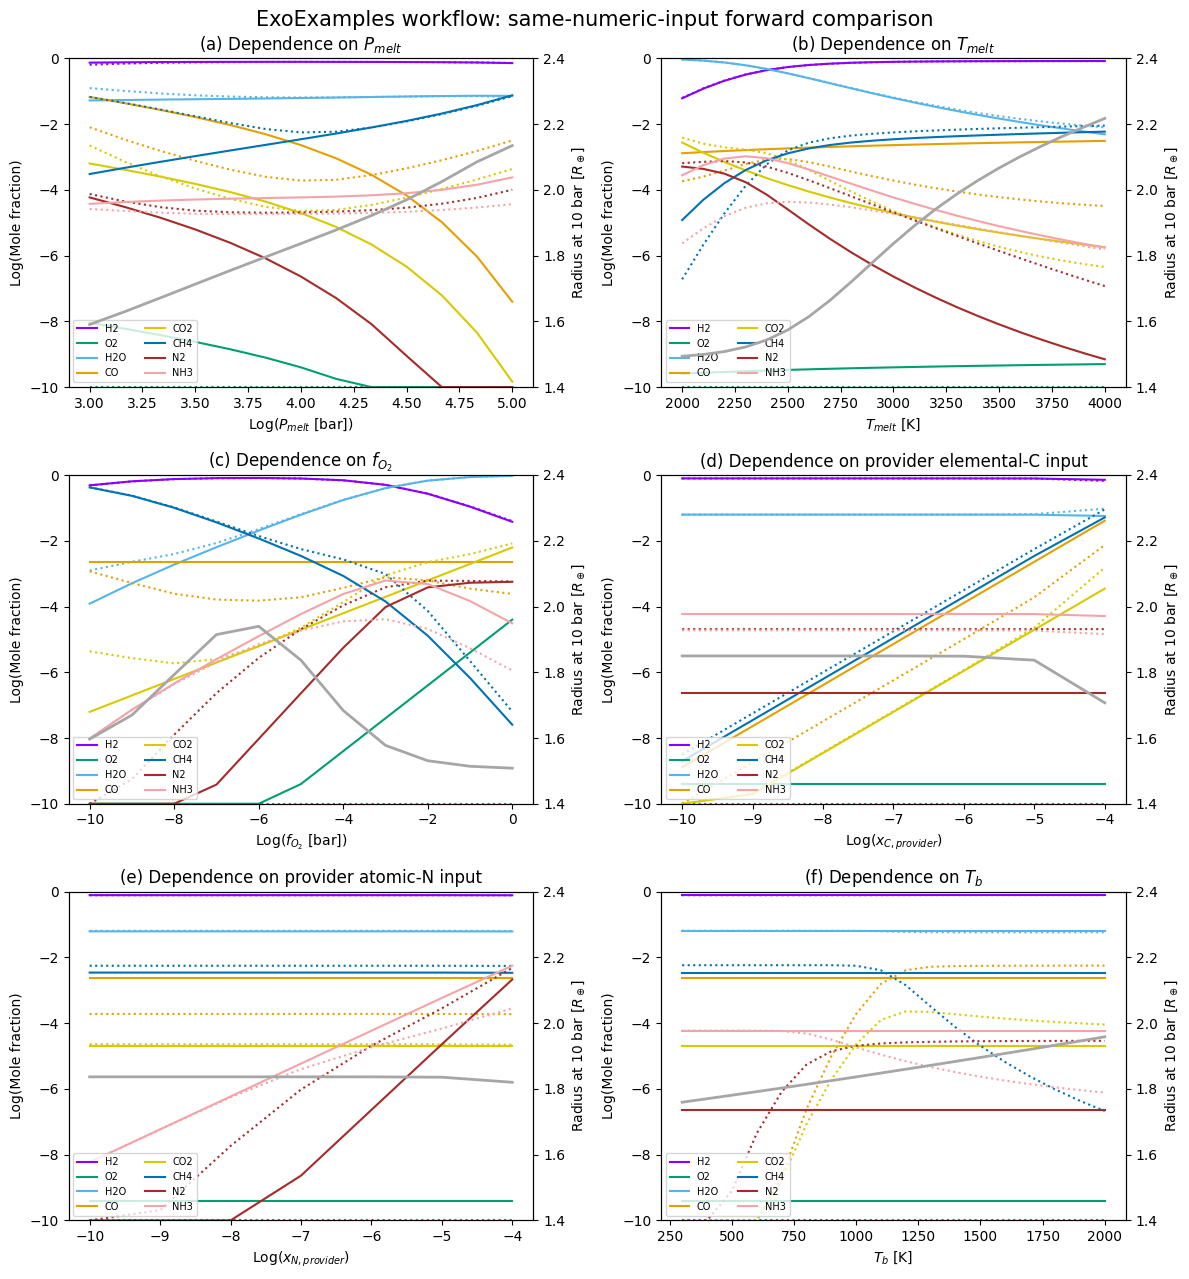

In [4]:
plot_forward_curves(RAW, language="en")
plt.show()

The figure above redraws the main example's same-numeric-input run from its CSV output. The broad shapes of the solid and dotted curves resemble Figure 8, but the C/N species and radius have systematic offsets. The next section separates the part explained solely by the input definition.

## 7. Comparison method for the published Figure 8

### 7.1 Limits of the vector reference

The paper does not publish a numerical table for Figure 8. This document converts `f8a_dep_pmelt_t.pdf` through `f8f_dep_tb_t.pdf` from the arXiv source to SVG and stores the centerline coordinates by color and solid/dotted style in [meltyq_figure8_vector_reference.csv](https://github.com/HajimeKawahara/exoexamples/blob/main/docs/meltyq/data/meltyq_figure8_vector_reference.csv). Curves outside the displayed vertical range cannot be determined and are excluded from comparison. Define

$$\Delta_s=\log_{10}x_s^{workflow}-\log_{10}x_s^{paper},\qquad \Delta_R=R_{10}^{workflow}-R_{10}^{paper}.$$

In data coordinates, half of the source line width is approximately 0.03190 dex for composition and 0.003190 $R_\oplus$ for radius. This is a visual indistinguishability scale for centerline differences, not a statistical uncertainty, error bar, or numerical-accuracy tolerance. Agreement finer than these scales is not called an exact match to the paper's numerical values.

### 7.2 Make the CO/N input bases explicit

MELTYQ Appendix A describes the law outputs as CO/N2 mass fractions and maps them to melt mole coordinates using a mean melt molar mass of 60 g mol$^{-1}$ and molecular masses. The primary sources and ExoGibbs instead treat the corresponding outputs as elemental-C/atomic-N mass fractions, with public dilute-mole coordinates based on 12.0107/14.0067 g mol$^{-1}$. Because the author code is unavailable, this document assumes an **operational mapping of the same numerical law output from the paper-labelled coordinate to the provider coordinate**:

$$x_{C,Exo}=x_{CO,paper}\frac{28.0101}{12.0107}=2.332095548\,x_{CO,paper},$$

$$x_{N,Exo}=x_{N_2,paper}\frac{28.0134}{14.0067}=2\,x_{N_2,paper}.$$

The large improvement in the vector-curve match strongly supports this mapping, but it is not a direct check of the unpublished author table or code. This is an application-level transformation from paper coordinates to a provider contract, not a pair-specific physics adapter, so it belongs to ExoExamples. The main example does not silently apply it and preserves a same-numeric-input run. The basis-aligned sensitivity run used below retains the paper coordinate in `sweep_value`, while explicitly applying the formula to the baseline and C/N sweep values passed to the provider.

In [5]:
def residual_summary(frame):
    values = frame["delta"].abs()
    return {
        "n": len(values),
        "median_abs": values.median(),
        "p90_abs": values.quantile(0.90),
        "p95_abs": values.quantile(0.95),
        "max_abs": values.max(),
    }


raw_surface = COMPARISON[
    (COMPARISON["label"] == "raw")
    & (COMPARISON["endpoint"] == "surface")
    & COMPARISON["visible"]
]
raw_base = COMPARISON[
    (COMPARISON["label"] == "raw")
    & (COMPARISON["endpoint"] == "base")
    & COMPARISON["visible"]
]
aligned_clean = COMPARISON[
    (COMPARISON["label"] == "basis-aligned")
    & (COMPARISON["endpoint"] != "radius")
    & COMPARISON["visible"]
    & ~(
        (COMPARISON["sweep"] == "pressure_melt")
        & COMPARISON["species"].isin(["N2", "NH3"])
    )
]
aligned_radius = COMPARISON[
    (COMPARISON["label"] == "basis-aligned")
    & (COMPARISON["endpoint"] == "radius")
]
fortney_delta = aligned_radius["counterfactual_delta"]

print("Raw surface:", residual_summary(raw_surface))
print("Raw 10 bar:", residual_summary(raw_base))
print("Basis aligned, excluding P_melt N curves:")
print(residual_summary(aligned_clean))
print(
    "Published composition half-linewidth: "
    f"{PAPER_COMPOSITION_HALF_LINEWIDTH_DEX:.5f} dex"
)
print(
    "Basis-aligned radius delta [R_earth]: "
    f"min={aligned_radius.delta.min():.5f}, "
    f"median={aligned_radius.delta.median():.5f}, "
    f"p90={aligned_radius.delta.quantile(0.90):.5f}, "
    f"max={aligned_radius.delta.max():.5f}"
)
print(
    "Same-density-profile Fortney rocky-boundary counterfactual: "
    f"min={fortney_delta.min():.5f}, "
    f"median={fortney_delta.median():.5f}, "
    f"max={fortney_delta.max():.5f} R_earth"
)
print(
    "Hydrostatically propagated median rocky-boundary effect: "
    f"{(aligned_radius.model - aligned_radius.counterfactual_model).median():.5f} "
    "R_earth"
)
print(
    "Fortney rocky-boundary samples inside the paper radius half-stroke: "
    f"{(fortney_delta.abs() <= PAPER_RADIUS_HALF_LINEWIDTH_REARTH).sum()}"
    f"/{len(fortney_delta)}"
)

endpoint_species = (
    COMPARISON[
        (COMPARISON["label"] == "basis-aligned")
        & COMPARISON["endpoint"].isin(["surface", "base"])
        & COMPARISON["species"].isin(SPECIES[:6])
        & COMPARISON["visible"]
    ]
    .assign(absolute_delta=lambda frame: frame["delta"].abs())
    .groupby(["endpoint", "species"])["absolute_delta"]
    .agg(
        n="size",
        median_abs="median",
        max_abs="max",
        fraction_within_half_stroke=lambda values: np.mean(
            values <= PAPER_COMPOSITION_HALF_LINEWIDTH_DEX
        ),
    )
)
print("\nBasis-aligned H/O/C differences by endpoint [dex]:")
print(endpoint_species.to_string(float_format=lambda value: f"{value:.6f}"))

baseline_rows = []
for species in SPECIES:
    values = {"species": species}
    for endpoint in ("surface", "base"):
        selected = COMPARISON[
            (COMPARISON["sweep"] == "pressure_melt")
            & np.isclose(COMPARISON["sweep_value"], 1.0e4)
            & (COMPARISON["species"] == species)
            & (COMPARISON["endpoint"] == endpoint)
        ]
        raw_record = selected[selected["label"] == "raw"].iloc[0]
        aligned_record = selected[
            selected["label"] == "basis-aligned"
        ].iloc[0]
        values[f"paper {endpoint}"] = aligned_record.paper
        values[f"raw {endpoint}"] = raw_record.model
        values[f"aligned {endpoint}"] = aligned_record.model
    baseline_rows.append(values)
print("\nBaseline log10 gas-composition anchor:")
print(
    pd.DataFrame(baseline_rows).to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

Raw surface: {'n': 595, 'median_abs': 0.3421188525366392, 'p90_abs': 0.5694041196903696, 'p95_abs': 0.6009131984348732, 'max_abs': 5.6183678412769975}
Raw 10 bar: {'n': 525, 'median_abs': 0.3495607924284432, 'p90_abs': 0.6115764234995413, 'p95_abs': 0.8201718959875416, 'max_abs': 5.204471445146161}
Basis aligned, excluding P_melt N curves:
{'n': 1073, 'median_abs': 0.002393009569685134, 'p90_abs': 0.02951546680573616, 'p95_abs': 0.036647383737805225, 'max_abs': 0.584369649960296}
Published composition half-linewidth: 0.03190 dex
Basis-aligned radius delta [R_earth]: min=0.00194, median=0.00716, p90=0.00844, max=0.00948
Same-density-profile Fortney rocky-boundary counterfactual: min=-0.00173, median=0.00251, max=0.00385 R_earth
Hydrostatically propagated median rocky-boundary effect: 0.00465 R_earth
Fortney rocky-boundary samples inside the paper radius half-stroke: 70/77

Basis-aligned H/O/C differences by endpoint [dex]:
                   n  median_abs  max_abs  fraction_within_half_

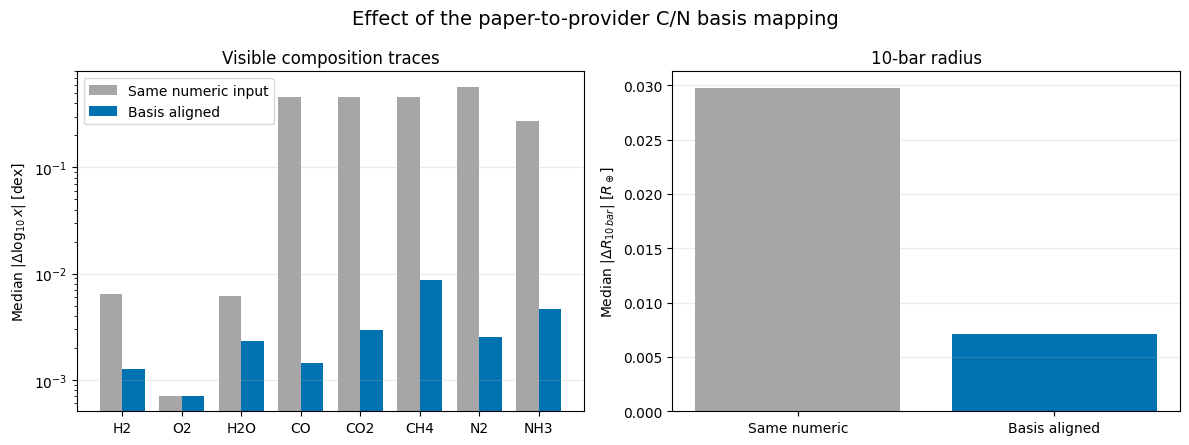

In [6]:
plot_basis_mapping_effect(COMPARISON, language="en")
plt.show()

For the same-numeric run, the median absolute difference over visible traces was 0.342 dex in the $P_{melt}$ gas and 0.350 dex in the 10-bar gas. After basis alignment, the 1,073 **matched plotted-trace samples** (not independent physical points) excluding the N2/NH3 pressure-sweep traces have a median of 0.00239 dex and a 90th percentile of 0.02952 dex. Every surface H/O/C sample lies within the paper half-stroke, but at 10 bar the CO median is 0.03586 dex and endpoint outliers remain for CO2, CH4, and others. Typical trends therefore improve to the plotted line-width scale; this is not numerical agreement of every trace. The dominant raw offset is clearly associated with identifying unlike C/N input bases, not with root nonconvergence.

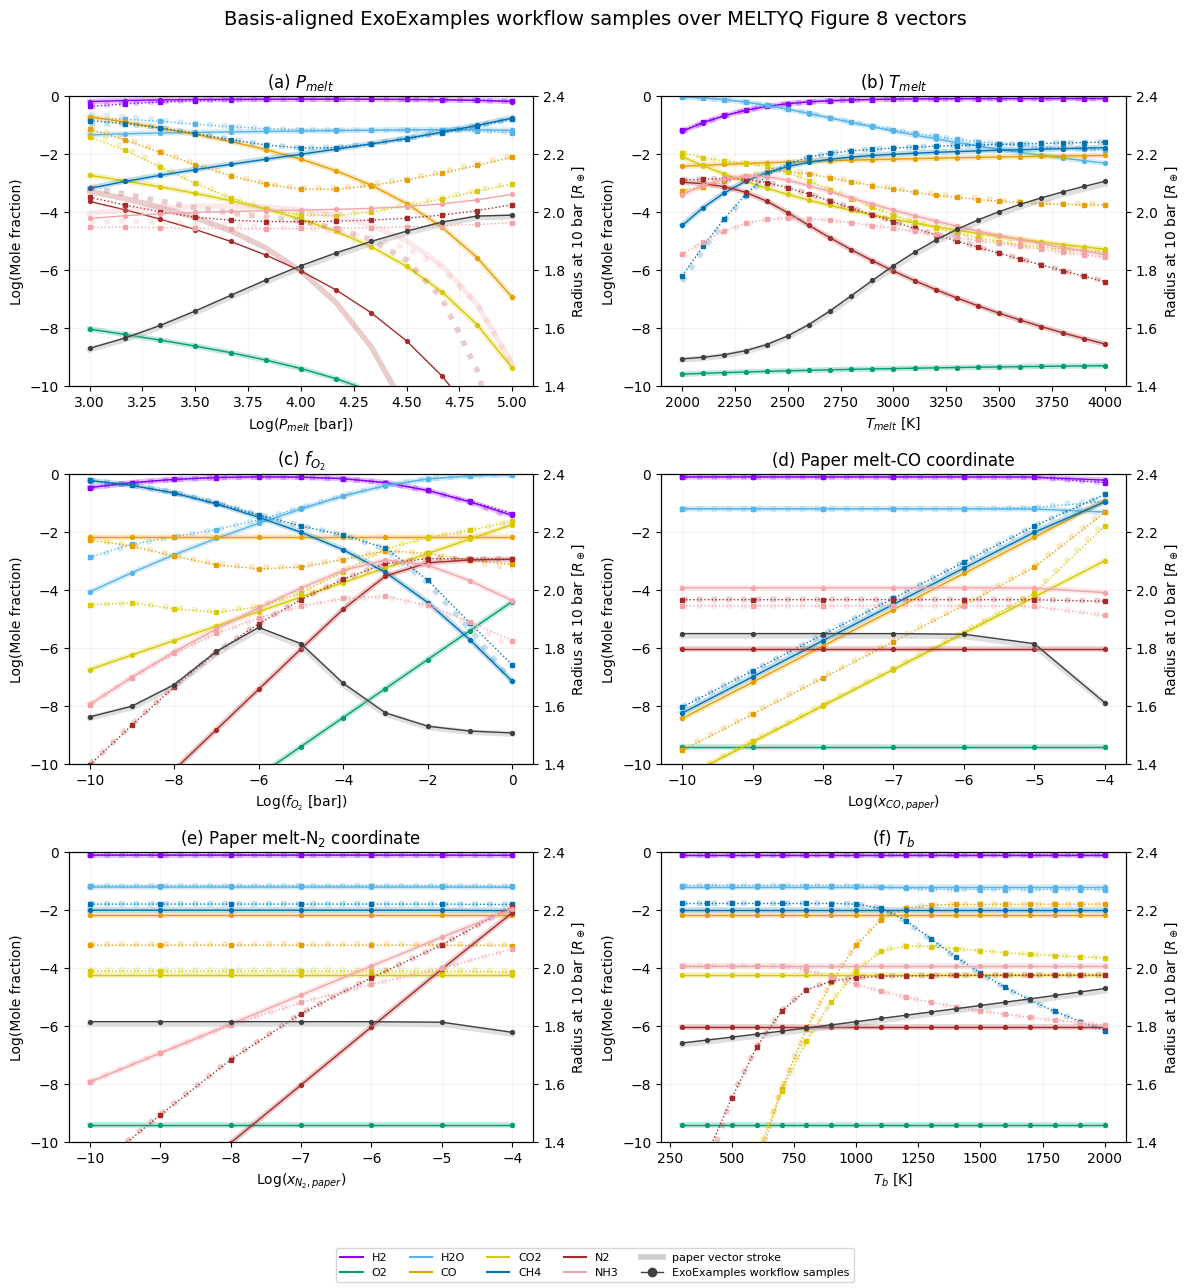

In [7]:
plot_basis_aligned_overlay(COMPARISON, REFERENCE, language="en")
plt.show()

Thick translucent lines are the published vector strokes; thin lines and markers are the basis-aligned ExoExamples workflow samples. Solid/circles denote the $P_{melt}$ gas and dotted/squares the 10-bar gas. The workflow combines ExoFamily providers with the external ExoPie boundary; it does not make ExoPie part of ExoFamily. Overlap directly shows agreement of plotted trends, but the stroke width is not an uncertainty. The high-pressure N discrepancy in panel (a) and small differences in several 10-bar traces remain visible.

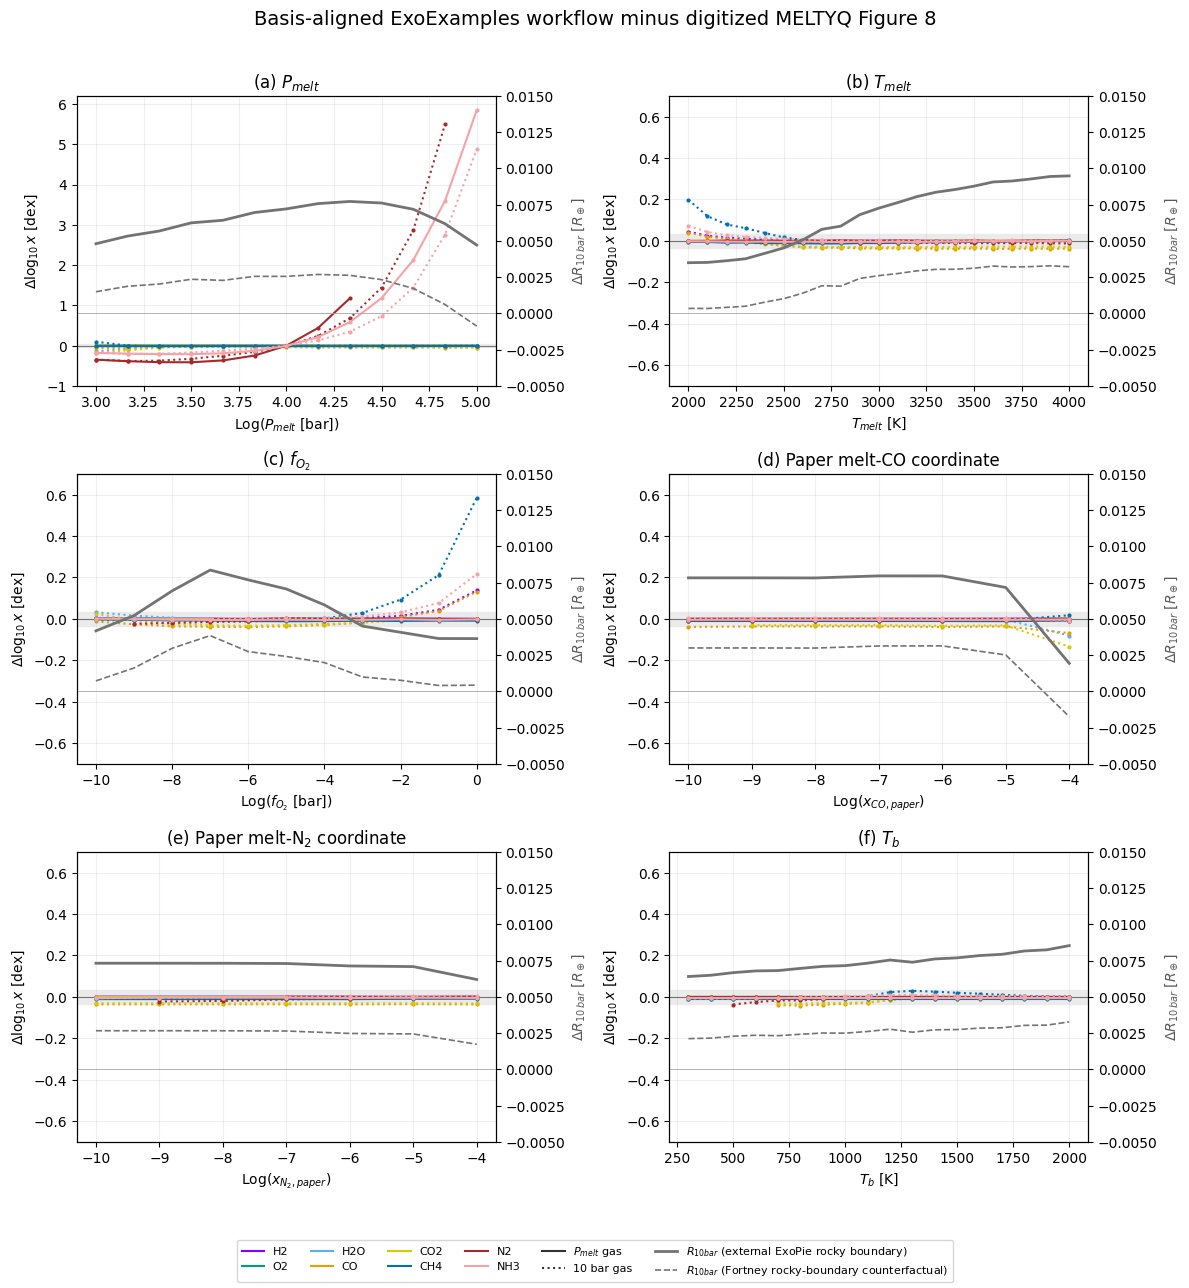

In [8]:
plot_basis_aligned_differences(COMPARISON, language="en")
plt.show()

The gray band shows half the published composition-line width as a visual scale, not an uncertainty. Colored lines show the current ExoExamples workflow minus the paper vector centerline. The solid gray curve uses the external ExoPie rocky lower boundary $R_{\mathrm{rock}}$, whereas the dashed gray curve replaces only $R_{\mathrm{rock}}$ with the Fortney rocky-body value for the same density profile. Neither quantity is a metallic-core radius. Most composition curves cluster near zero, but N2 and NH3 in panel (a) separate by several dex at high pressure.

### 7.3 Appendix pressure units and the high-pressure N-law difference

The MELTYQ Appendix labels the CO-solubility pressure in GPa, whereas the primary source and ExoGibbs use bar. Conversely, it labels the CH4-solubility pressure in bar, whereas the primary source and ExoGibbs use GPa. Both the equations in this document and the implementation follow the primary-source conventions, so these are not runtime unit-conversion bugs. The convention used by the unpublished author code nevertheless remains unknown.

MELTYQ Appendix A6 typesets $5908P_{melt}/T$ in the N-solubility exponent, and the high-pressure N curves in published Figure 8 are consistent with this linear-$P$ form. The primary source, [Dasgupta et al. (2022), Equation 10](https://doi.org/10.1016/j.gca.2022.09.012), instead uses $5908\sqrt{P_{melt}}/T$, and ExoGibbs follows the primary source. The difference is small near the 1-GPa baseline, but at 10 GPa NH3 in the $P_{melt}$ gas is -9.240 dex in the paper digitization and -3.393 dex in ExoGibbs, a +5.847-dex difference. This observation is consistent with the formula variant and is not a solver failure, but it does not establish the implementation in the unpublished author code.

The primary-source-consistent ExoGibbs default should not be changed to match a published formula or implementation variant. Only a future requirement for pixel-level legacy reproduction of Figure 8 would justify an explicit opt-in compatibility mode in ExoGibbs.

### 7.4 Radius difference

After basis alignment, the radius from the current ExoExamples workflow is larger in all 77 panel entries: +0.00194 to +0.00948 $R_\oplus$, with a median of +0.00716 $R_\oplus$. The corrected Fortney et al. relation used by MELTYQ gives a 1.44231987-$R_\oplus$ rocky lower-boundary radius for 4 $M_\oplus$ and 33% iron, whereas external ExoPie gives $R_{\mathrm{rock}}=1.44527308R_\oplus$; the lower boundaries differ by 0.002953 $R_\oplus$. Because $g\propto r^{-2}$, that number must not be subtracted directly from the 10-bar difference. For each saved density profile, define

$$
I_\rho=R_{\mathrm{rock}}^{-1}-R_{10}^{-1},
\qquad
R_{10}^{\mathrm{Fortney}}=\left[(R_{\mathrm{rock}}^{\mathrm{Fortney}})^{-1}-I_\rho\right]^{-1}.
$$

Replacing only $R_{\mathrm{rock}}$ with the Fortney value lowers the 10-bar radius by a median 0.004653 $R_\oplus$. The paper residual then has a minimum of -0.001732, median +0.002512, and maximum +0.003850 $R_\oplus$, with 70/77 samples inside the paper half-stroke. This same-density-profile counterfactual shows that the rocky-boundary prescription explains most of the offset, while the residual still mixes EOS/structure differences with digitization.

## 8. What agrees and what remains uncertain

| Item | Present assessment |
|---|---|
| H/O/C gas chemistry | Every matched surface sample lies inside the paper half-stroke. The 10-bar traces are typically at the line-width scale, but a small systematic CO difference and endpoint outliers remain. Exact author-number agreement is untested. |
| N chemistry | The 1-GPa baseline and N-input sweep are typically close. The $P_{melt}$ discrepancy is consistent with the published linear-$P$ form versus the ExoGibbs $\sqrt P$ form. |
| 10-bar radius | The curve shape is close, with a positive offset. A Fortney rocky-boundary counterfactual removes most of it. |
| Convergence | Outer, inner, profile, and base flags are true at all 72 unique points in both runs. Nonconvergence does not obstruct this comparison. |
| Sampling | Inferred from vector art; it is not guaranteed to be the paper's original calculation grid. |
| Thermochemistry | Temperature dependence is confirmed, but the probes do not certify the full temperature range. |
| Deep discretization | Currently 64 layers; the paper's layer count is unpublished. |
| Physical calibration domain | Sensitivity endpoints including $T_{melt}=4000$ K, $T_b=300$ K, and $P_{melt}=10$ GPa may extrapolate EOS or solubility laws beyond their calibration domains. Reproducing the figure is not physical validation of those extrapolated predictions. |
| Upper atmosphere / spectrum / retrieval | Not included in this Figure 8 example. |

Input-basis alignment is an ExoExamples application responsibility, so it requires no ExoFamily change. The primary-source-consistent N law also requires no default change. Only future published-A6 compatibility would require an explicit ExoGibbs variant.

## 9. Regeneration

The model environment needs `pandas`, `matplotlib`, `ipykernel`, the ExoFamily provider dependencies, and the third-party ExoPie dependency; the conversion environment needs `jupyter-nbconvert` and Pandoc. The Japanese figures use `Noto Sans CJK JP`. Because a generic `python3` kernel can point to another environment, register a dedicated kernel with the model environment's absolute executable once, then run from the repository root.

```console
python -m ipykernel install --user --name exoexamples --display-name "Python (ExoExamples)"
JAX_PLATFORMS=cpu jupyter-nbconvert --to notebook --execute --inplace docs/en/meltyq/meltyq_figure8_forward_comparison_en.ipynb --ExecutePreprocessor.timeout=900 --ExecutePreprocessor.kernel_name=exoexamples
jupyter-nbconvert --to rst --no-prompt --template-file=docs/meltyq/rst_with_cell_spacing.j2 --output-dir docs/en/meltyq docs/en/meltyq/meltyq_figure8_forward_comparison_en.ipynb
```

To re-extract the paper's vector reference, unpack the arXiv source and run the following command. `pdftocairo` is required.

```console
python docs/meltyq/extract_meltyq_figure8_reference.py /path/to/meltyq-source docs/meltyq/data/meltyq_figure8_vector_reference.csv
```

Result metadata records a fingerprint of the ExoExamples calculation sources, imported runtime versions, the Python source inventories of ExoGibbs, ExoEOS, ExoJAX, and the external ExoPie package, and ExoPie's packaged mass-radius data tables, together with the generation time and SHA-256 hashes and sizes of the generated CSV and PNG. Python changes in editable installs, ExoPie data-table changes, and changed or damaged generated artifacts therefore trigger automatic regeneration. Other non-Python assets, native libraries, and backend-environment differences remain outside this scope; prefix the notebook command with `EXOEXAMPLES_FORCE_MELTYQ_DOCUMENT_RESULTS=1` when they matter. The regeneration command fixes the CPU backend for a cross-platform reference. JAX executables are stored in `.cache/jax` by default, and an existing `JAX_COMPILATION_CACHE_DIR` setting is respected.

## 10. Conclusion

This example uses ExoExamples to connect the ExoFamily providers (ExoGibbs, ExoEOS, and ExoJAX) with the external third-party ExoPie rocky-radius interpolation, evaluating the magma-surface gas, deep equilibrium, 10-bar gas, density, and radius as one forward map. Every current point converges, and JIT reuse is effective. The first obstacle to a direct Figure 8 comparison was the CO/N input basis. After the operational mapping, every matched surface H/O/C sample and the typical trends including 10 bar approach the published stroke-width scale. Some 10-bar outliers remain, together with a high-pressure N discrepancy consistent with the formula variant and a radius offset largely reduced by the rocky-boundary prescription. The supported conclusion is therefore that the current ExoExamples workflow reproduces most forward trends in MELTYQ Figure 8 and isolates remaining differences by interface or model variant—not that it exactly reproduces the paper's unpublished numerical data.

### References

- Ito, Y. & Changeat, Q. 2026, *The Astrophysical Journal*, 1006:37, [doi:10.3847/1538-4357/ae6917](https://doi.org/10.3847/1538-4357/ae6917), CC BY 4.0.
- Zhang, C. & Duan, Z. 2009, *Geochimica et Cosmochimica Acta*, [doi:10.1016/j.gca.2009.01.021](https://doi.org/10.1016/j.gca.2009.01.021).
- Chabrier, G. & Debras, F. 2021, *The Astrophysical Journal*, [doi:10.3847/1538-4357/abfc48](https://doi.org/10.3847/1538-4357/abfc48).
- Plotnykov, M. & Valencia, D. 2024, *Observation uncertainty effects on the precision of interior planetary parameters*, *Monthly Notices of the Royal Astronomical Society*, 530, 3488--3499, [doi:10.1093/mnras/stae993](https://doi.org/10.1093/mnras/stae993); software: [ExoPie GitHub repository](https://github.com/mplotnyko/exopie/).
- Hirschmann et al. 2012, *Earth and Planetary Science Letters*, [doi:10.1016/j.epsl.2012.06.031](https://doi.org/10.1016/j.epsl.2012.06.031).
- Hirschmann, M. M. 2021, *Geochimica et Cosmochimica Acta*, [doi:10.1016/j.gca.2021.08.039](https://doi.org/10.1016/j.gca.2021.08.039).
- Lichtenberg et al. 2021, *Journal of Geophysical Research: Planets*, [doi:10.1029/2020JE006711](https://doi.org/10.1029/2020JE006711).
- Yoshioka et al. 2019, *Geochimica et Cosmochimica Acta*, [doi:10.1016/j.gca.2019.06.007](https://doi.org/10.1016/j.gca.2019.06.007).
- Ardia et al. 2013, *Geochimica et Cosmochimica Acta*, [doi:10.1016/j.gca.2013.03.028](https://doi.org/10.1016/j.gca.2013.03.028).
- Dasgupta et al. 2022, *Geochimica et Cosmochimica Acta*, [doi:10.1016/j.gca.2022.09.012](https://doi.org/10.1016/j.gca.2022.09.012).
- Fortney, Marley & Barnes 2007, [doi:10.1086/512120](https://doi.org/10.1086/512120); corrected coefficients in the [erratum](https://doi.org/10.1086/521435).